What are the top-demand skills for the top 3 most popular data roles ?

Methodology

1.Clean-up skill column
2.Calculate skill count based on job titile short 
3.Calculate skill percentage
4.Plot final findings 


In [60]:
#importing Libraries 
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Loading Data
dataset=load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

In [3]:
#Cleanup Data
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x:ast.literal_eval(x) if pd.notna(x)else x)

In [4]:
df_UK = df[df['job_country']=='United Kingdom']

In [ ]:
#Transform list of job skills into rows with repeating index
df_skills=df_UK.explode('job_skills')

In [7]:
df_skills[['job_title_short','job_skills']]

,job_title_short,job_skills
15,Data Engineer,python
15,Data Engineer,sql
15,Data Engineer,power bi
45,Senior Data Analyst,sql
45,Senior Data Analyst,python
...,...,...
785642,Data Engineer,qlik
785642,Data Engineer,confluence
785642,Data Engineer,jira
785676,Senior Data Scientist,r


In [17]:
df_skills_count=df_skills.groupby(['job_skills','job_title_short']).size()

In [18]:
type(df_skills_count)

pandas.Series

In [ ]:
#Convert series into dataframe 
df_skills_count=df_skills_count.reset_index(name = 'skill_count')

In [22]:
df_skills_count.sort_values(by='skill_count',ascending = False,inplace = True)

In [23]:
df_skills_count

,job_skills,job_title_short,skill_count
1163,sql,Data Engineer,7050
915,python,Data Engineer,6462
916,python,Data Scientist,6329
88,azure,Data Engineer,4865
1162,sql,Data Analyst,4467
...,...,...,...
1368,vue.js,Software Engineer,1
1367,vue.js,Senior Data Engineer,1
514,javascript,Machine Learning Engineer,1
551,julia,Software Engineer,1


In [27]:
job_titles = df_skills_count['job_title_short'].unique().tolist()

In [ ]:
#Get top 3 job titles sorted
job_titles=sorted(df['job_title_short'][:3])

In [31]:
job_titles

['Data Analyst', 'Data Engineer', 'Senior Data Engineer']

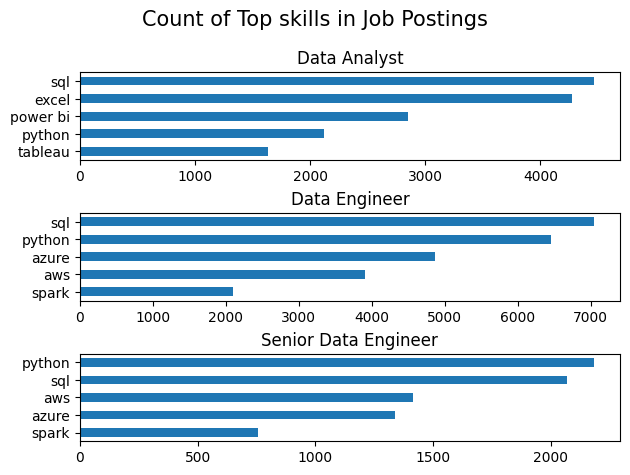

In [51]:
fig , ax = plt.subplots(len(job_titles),1)

for i ,job_title in enumerate(job_titles):
    df_plot=df_skills_count[df_skills_count['job_title_short']==job_title].head(5)
    df_plot.plot(kind ='barh',x = 'job_skills',y='skill_count',ax=ax[i],title = job_title)
    ax[i].invert_yaxis()
    ax[i].set_ylabel("")
    ax[i].legend().set_visible(False)


fig.suptitle('Count of Top skills in Job Postings',fontsize =15)
plt.tight_layout(h_pad=0.5)
plt.show()



In [47]:
df_job_title_count=df_UK['job_title_short'].value_counts().reset_index(name = 'jobs_total')

In [52]:
df_job_title_count

,job_title_short,jobs_total
0,Data Engineer,11807
1,Data Analyst,10482
2,Data Scientist,9148
3,Senior Data Engineer,3337
4,Senior Data Scientist,2367
5,Senior Data Analyst,1356
6,Business Analyst,827
7,Software Engineer,541
8,Machine Learning Engineer,317
9,Cloud Engineer,193


In [48]:
df_skills_perc=pd.merge(df_skills_count,df_job_title_count,how='left',on='job_title_short')

In [53]:
df_skills_perc

,job_skills,job_title_short,skill_count,jobs_total,skill_percent
0,sql,Data Engineer,7050,11807,59.710341
1,python,Data Engineer,6462,11807,54.730245
2,python,Data Scientist,6329,9148,69.184521
3,azure,Data Engineer,4865,11807,41.204370
4,sql,Data Analyst,4467,10482,42.615913
...,...,...,...,...,...
1414,vue.js,Software Engineer,1,541,0.184843
1415,vue.js,Senior Data Engineer,1,3337,0.029967
1416,javascript,Machine Learning Engineer,1,317,0.315457
1417,julia,Software Engineer,1,541,0.184843


In [54]:
df_skills_perc['skill_percent'] = 100*df_skills_perc['skill_count'] / df_skills_perc['jobs_total']

In [55]:
df_skills_perc

,job_skills,job_title_short,skill_count,jobs_total,skill_percent
0,sql,Data Engineer,7050,11807,59.710341
1,python,Data Engineer,6462,11807,54.730245
2,python,Data Scientist,6329,9148,69.184521
3,azure,Data Engineer,4865,11807,41.204370
4,sql,Data Analyst,4467,10482,42.615913
...,...,...,...,...,...
1414,vue.js,Software Engineer,1,541,0.184843
1415,vue.js,Senior Data Engineer,1,3337,0.029967
1416,javascript,Machine Learning Engineer,1,317,0.315457
1417,julia,Software Engineer,1,541,0.184843


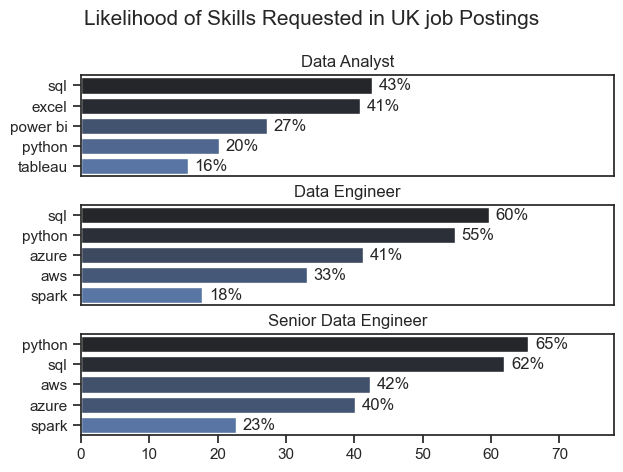

In [87]:
fig , ax = plt.subplots(len(job_titles),1)

sns.set_theme(style='ticks')

for i ,job_title in enumerate(job_titles):
    df_plot=df_skills_perc[df_skills_perc['job_title_short']==job_title].head(5)
    #df_plot.plot(kind ='barh',x = 'job_skills',y='skill_percent',ax=ax[i],title = job_title)
    #print(df_plot)
    sns.barplot(data= df_plot, x ='skill_percent' ,y='job_skills',ax=ax[i],hue='skill_count',palette='dark:b_r')
    #ax[i].invert_yaxis()
    ax[i].set_title(job_title)
    ax[i].set_ylabel("")
    ax[i].set_xlabel("")

    ax[i].get_legend().remove()
    ax[i].set_xlim(0,78)

#This code is used to create datalabels in horizontal bar chart.
#In a horizontal bar chart, the bars are plotted at these integer positions on the Y-axis.
    for n,v in enumerate(df_plot['skill_percent']):
        ax[i].text(v + 1, n, f'{v:.0f}%',va='center')

    if i!=len(job_titles)-1:
        ax[i].set_xticks([])


fig.suptitle('Likelihood of Skills Requested in UK job Postings',fontsize =15)
plt.tight_layout(h_pad=0.5)
plt.show()


